In [ ]:
import torch  # 导入PyTorch库
import torch.nn as nn  # 导入PyTorch神经网络模块
import math  # 导入数学函数库
from torch.nn import functional as F  # 导入PyTorch函数式API

# 定义相对位置编码模块，相对位置编码是有参数的，可训练的
class RelativePositionEmbedding(nn.Module):
    '''
    相对位置编码模块，相对位置编码是有参数的，可训练的
    参数：
        max_seq_len: 最大序列长度，用于限制输入序列的最大长度
        embedding_dim: 嵌入维度，表示每个位置编码向量的维度大小
    
    方法：
        forward: 前向传播，生成相对位置嵌入
        _generate_relative_positions_matrix: 生成相对位置矩阵
    '''
    def __init__(self, max_seq_len: int, embedding_dim: int):
        '''
        初始化方法，初始化相对位置编码模块
        参数：
            max_seq_len: 最大序列长度，用于限制输入序列的最大长度
            embedding_dim: 嵌入维度，表示每个位置编码向量的维度大小
        '''
        super().__init__()  # 调用父类初始化方法
        self.max_seq_len = max_seq_len  # 最大序列长度，用于限制输入序列的最大长度
        self.embedding_dim = embedding_dim  # 嵌入维度，表示每个位置编码向量的维度大小
        self.relative_positions = nn.Parameter(torch.randn(max_seq_len * 2 - 1, embedding_dim))  # 创建相对位置嵌入参数矩阵，行数为最大相对距离数(2*max_seq_len-1)，列数为embedding_dim
    
    def forward(self, seq_len: int):
        '''
        前向传播，生成相对位置嵌入
        参数：
            seq_len: 序列长度，用于生成相对位置矩阵
        '''
        relative_positions_matrix = self._generate_relative_positions_matrix(seq_len)  # 调用私有方法生成相对位置矩阵，矩阵大小为seq_len x seq_len
        relative_embeddings = F.embedding(relative_positions_matrix, self.relative_positions)  # 使用F.embedding查找相对位置编码，将位置索引映射为对应的嵌入向量
        return relative_embeddings  # 返回相对位置嵌入结果，形状为[seq_len, seq_len, embedding_dim]
    
    def _generate_relative_positions_matrix(self, seq_len: int):
        '''
        生成相对位置矩阵
        参数：
            seq_len: 序列长度，用于生成相对位置矩阵
        '''
        range_vec = torch.arange(seq_len)  # 创建从0到seq_len-1的序列向量，用于计算相对位置
        range_matrix = range_vec.unsqueeze(0).expand(seq_len, seq_len)  # 将序列向量扩展为矩阵，每行都是相同的序列
        distance_matrix = range_matrix - range_matrix.t()  # 计算位置差距矩阵，每个元素表示行列索引之间的距离
        distance_matrix = distance_matrix + self.max_seq_len - 1  # 将负的相对位置偏移为非负值，确保所有索引都是非负的
        return distance_matrix  # 返回最终的相对位置矩阵

# 定义多头注意力模块，实现带相对位置编码的多头自注意力机制
class MultiHeadAttention(nn.Module):
    '''
    多头注意力模块，实现带相对位置编码的多头自注意力机制
    参数：
        embed_dim: 嵌入维度，表示输入向量的维度
        num_heads: 注意力头数，将注意力机制分成多个子空间
        max_seq_len: 最大序列长度，用于限制输入序列的最大长度
    
    方法：
        forward: 前向传播，计算多头注意力
        _generate_relative_positions_matrix: 生成相对位置矩阵
    '''
    def __init__(self, embed_dim: int, num_heads: int, max_seq_len: int):
        '''
        初始化方法，初始化多头注意力模块
        参数：
            embed_dim: 嵌入维度，表示输入向量的维度
            num_heads: 注意力头数，将注意力机制分成多个子空间
            max_seq_len: 最大序列长度，用于限制输入序列的最大长度
        '''
        super().__init__()  # 调用父类初始化方法
        self.embed_dim = embed_dim  # 模型的嵌入维度，表示输入向量的维度
        self.num_heads = num_heads  # 注意力头的数量，将注意力分成多个子空间
        self.head_dim = embed_dim // num_heads  # 每个注意力头的维度，由总维度平均分配
        self.q_proj = nn.Linear(embed_dim, embed_dim)  # 查询向量的线性变换层，将输入转换为查询向量
        self.k_proj = nn.Linear(embed_dim, embed_dim)  # 键向量的线性变换层，将输入转换为键向量
        self.v_proj = nn.Linear(embed_dim, embed_dim)  # 值向量的线性变换层，将输入转换为值向量
        self.rel_pos_embeddings = RelativePositionEmbedding(max_seq_len, self.head_dim)  # 初始化相对位置编码模块，维度为每个头的维度
        self.out_proj = nn.Linear(embed_dim, embed_dim)  # 输出的线性变换层，将多头注意力的结果映射回原始维度
    
    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor):
        '''
        前向传播，计算多头注意力
        参数：
            query: 查询张量，形状为[batch_size, seq_len, embed_dim]
            key: 键张量，形状为[batch_size, seq_len, embed_dim]
            value: 值张量，形状为[batch_size, seq_len, embed_dim]
        '''
        batch_size, seq_len, embed_dim = query.size()  # 获取输入张量的形状信息：批次大小、序列长度、嵌入维度
        
        # 对查询、键、值进行线性变换并重塑为多头形式
        query = self.q_proj(query).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # 将查询向量变换并重排为多头形式
        key = self.k_proj(key).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # 将键向量变换并重排为多头形式
        value = self.v_proj(value).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)  # 将值向量变换并重排为多头形式
        
        # 计算标准注意力分数
        attention_scores = torch.matmul(query, key.transpose(-1, -2))  # 计算查询和键的点积，得到注意力分数矩阵
        
        # 获取相对位置编码
        rel_pos_embeddings = self.rel_pos_embeddings(seq_len)  # 根据当前序列长度生成相对位置编码
        
        # 计算相对位置注意力分数
        rel_attention_scores = torch.einsum('bhld,lrd->bhlr', query, rel_pos_embeddings)  # 使用einsum计算查询与相对位置编码的注意力分数
        
        # 将相对位置信息添加到注意力分数中
        attention_scores += rel_attention_scores  # 将标准注意力分数和相对位置注意力分数相加
        
        # 对注意力分数进行缩放
        attention_scores = attention_scores / math.sqrt(self.head_dim)  # 使用头维度的平方根进行缩放，防止梯度消失
        
        # 计算注意力权重
        attention_weights = F.softmax(attention_scores, dim=-1)  # 对注意力分数应用softmax，获得注意力权重
        
        # 应用注意力权重到值向量
        output = torch.matmul(attention_weights, value)  # 将注意力权重与值向量相乘，得到加权结果
        
        # 重塑输出张量
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)  # 将多头注意力的结果重新排列为原始形状
        
        # 应用输出投影
        output = self.out_proj(output)  # 通过输出投影层处理最终结果
        return output  # 返回多头注意力的输出结果

# 示例代码：演示如何使用上述模块
max_seq_len = 10  # 设置最大序列长度，限制输入序列的最大长度
embed_dim = 64  # 设置嵌入维度，表示特征向量的维度
num_heads = 4  # 设置注意力头数，将注意力机制分成4个子空间
batch_size = 2  # 设置批次大小，同时处理的样本数
seq_len = 5  # 设置实际序列长度，当前输入序列的长度

query = torch.randn(batch_size, seq_len, embed_dim)  # 创建随机查询张量，模拟输入数据
key = torch.randn(batch_size, seq_len, embed_dim)  # 创建随机键张量，模拟输入数据
value = torch.randn(batch_size, seq_len, embed_dim)  # 创建随机值张量，模拟输入数据

attention = MultiHeadAttention(embed_dim, num_heads, max_seq_len)  # 实例化多头注意力模块，创建模型对象

# 测试各个组件的输出
print("相对位置矩阵:")  # 打印标题
print(attention.rel_pos_embeddings._generate_relative_positions_matrix(5))  # 显示5x5的相对位置矩阵
print(f"相对位置嵌入参数形状: {attention.rel_pos_embeddings.relative_positions.shape}")  # 显示相对位置嵌入参数的形状
print(f"序列长度为5的相对位置嵌入形状: {attention.rel_pos_embeddings(5).shape}")  # 显示序列长度为5时的相对位置嵌入形状

# 计算最终的注意力输出
output = attention(query, key, value)  # 使用多头注意力模块处理输入数据
print(f"输出形状: {output.shape}")  # 打印输出张量的形状，验证维度是否正确

相对位置矩阵:
tensor([[ 9, 10, 11, 12, 13],
        [ 8,  9, 10, 11, 12],
        [ 7,  8,  9, 10, 11],
        [ 6,  7,  8,  9, 10],
        [ 5,  6,  7,  8,  9]])
相对位置嵌入参数形状: torch.Size([19, 16])
序列长度为5的相对位置嵌入形状: torch.Size([5, 5, 16])
输出形状: torch.Size([2, 5, 64])


# 旋转位置编码

测试旋转位置编码(RoPE)
输入形状: torch.Size([2, 10, 128])
输出形状: torch.Size([2, 10, 128])
注意力权重形状: torch.Size([2, 8, 10, 10])

测试相对位置特性:
序列1注意力权重形状: torch.Size([1, 8, 5, 5])
序列2注意力权重形状: torch.Size([1, 8, 7, 7])
RoPE有助于保持序列中元素的相对位置关系

比较RoPE与绝对位置编码:
RoPE优势:
1. 更好的相对位置建模
2. 对序列长度的泛化能力更强
3. 在长序列上性能更稳定

绝对位置编码特点:
1. 直接添加到输入embeddings
2. 简单但可能丢失相对位置信息
3. 对序列长度敏感


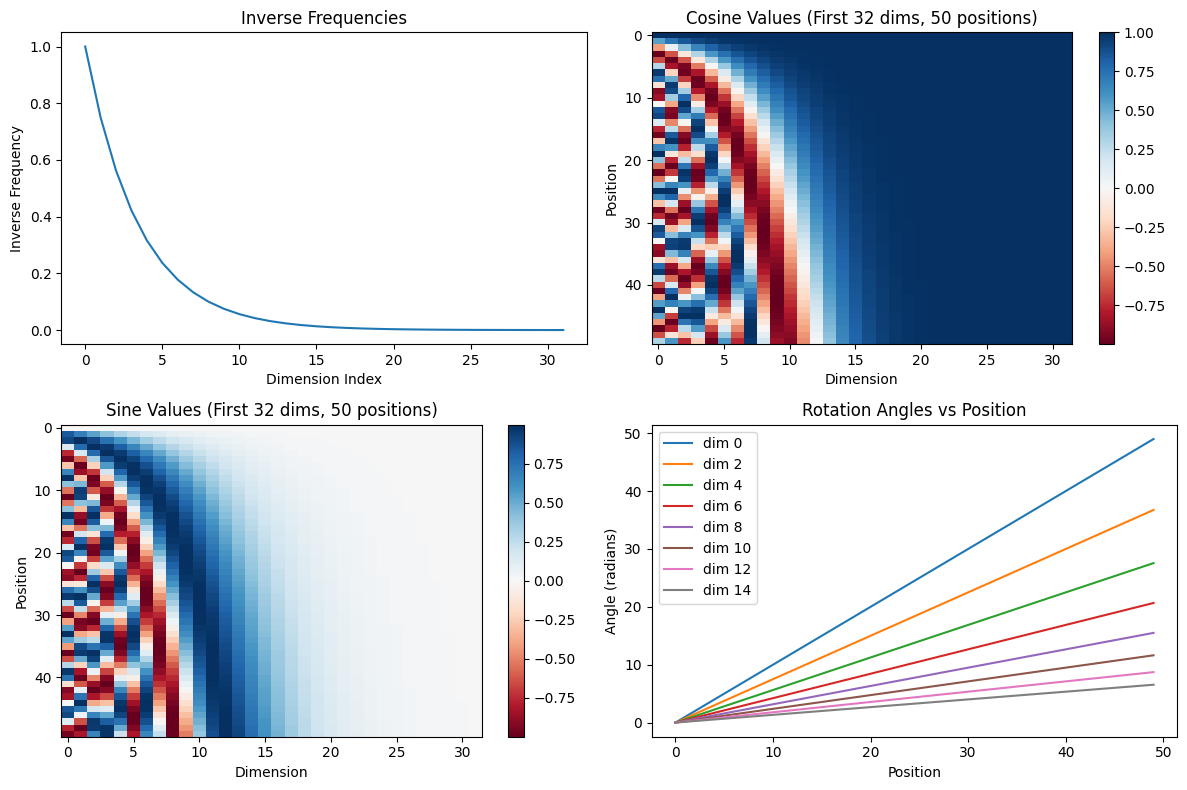


旋转位置编码(RoPE)示例完成！


In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import numpy as np

class RotaryPositionalEmbedding(nn.Module):
    '''
    旋转位置编码(RoPE - Rotary Position Embedding)
    
    RoPE的核心思想是通过旋转矩阵来编码位置信息，相对于绝对位置编码，
    RoPE能够更好地捕捉序列中元素的相对位置关系。
    '''
    
    def __init__(self, dim, max_position_embeddings=2048, base=10000):
        '''
        初始化方法，初始化旋转位置编码模块
        参数：
            dim: 特征维度
            max_position_embeddings: 最大序列长度
            base: 基础值
        '''
        super().__init__()  # 调用父类初始化
        self.dim = dim  # 存储特征维度
        self.max_position_embeddings = max_position_embeddings  # 存储最大序列长度
        self.base = base  # 存储基础值,用于计算频率
        
        # 计算倒数频率: 1 / (base^(2i/dim)), i从0到dim/2
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)  # 将倒数频率注册为缓冲区,不参与梯度更新
        
        # 预计算并缓存旋转矩阵的cos和sin值
        self._set_cos_sin_cache(max_position_embeddings)
    
    def _set_cos_sin_cache(self, seq_len):
        '''
        预计算cos和sin值
        参数：
            seq_len: 序列长度
        '''
        # 创建位置索引向量: [0, 1, ..., seq_len-1]
        t = torch.arange(seq_len, dtype=self.inv_freq.dtype, device=self.inv_freq.device)
        
        # 计算位置编码的角度: position * inv_freq, 得到[seq_len, dim//2]形状的矩阵
        freqs = torch.outer(t, self.inv_freq)
        
        # 将频率矩阵在最后一维拼接一次,扩展到完整维度[seq_len, dim]
        emb = torch.cat((freqs, freqs), dim=-1)
        
        # 计算并缓存cos值
        self.register_buffer('cos_cached', emb.cos())
        # 计算并缓存sin值
        self.register_buffer('sin_cached', emb.sin())
    
    def forward(self, x, seq_len=None):
        '''
        应用旋转位置编码
        参数：
            x: 输入张量
            seq_len: 序列长度
        返回：
            应用RoPE后的张量
        '''
        # 如果未指定序列长度,使用输入的序列长度
        if seq_len is None:
            seq_len = x.shape[1]
        
        # 如果序列长度超过缓存大小,重新计算cos和sin缓存
        if seq_len > self.cos_cached.shape[0]:
            self._set_cos_sin_cache(seq_len)
        
        # 获取当前序列长度对应的cos和sin值
        cos = self.cos_cached[:seq_len]
        sin = self.sin_cached[:seq_len]
        
        # 应用旋转位置编码并返回结果
        return self.apply_rotary_pos_emb(x, cos, sin)
    
    def apply_rotary_pos_emb(self, x, cos, sin):
        '''
        应用旋转位置编码的核心函数
        参数：
            x: 输入张量 [batch_size, seq_len, num_heads, head_dim]
            cos: cos值 [seq_len, head_dim]
            sin: sin值 [seq_len, head_dim]
        '''
        # 扩展cos和sin的维度以匹配输入x
        cos = cos.unsqueeze(0).unsqueeze(2)  # [1, seq_len, 1, head_dim]
        sin = sin.unsqueeze(0).unsqueeze(2)  # [1, seq_len, 1, head_dim]
        
        # 将输入x分成偶数和奇数索引,用于复数乘法
        x1, x2 = x[..., ::2], x[..., 1::2]  # x1,x2分别取偶数和奇数位置的值
        
        # 执行旋转操作(复数乘法): (a + bi)(cos θ + i sin θ) = (a cos θ - b sin θ) + i(a sin θ + b cos θ)
        rotated_x1 = x1 * cos[..., ::2] - x2 * sin[..., ::2]  # 实部
        rotated_x2 = x1 * sin[..., 1::2] + x2 * cos[..., 1::2]  # 虚部
        
        # 创建输出张量
        rotated_x = torch.zeros_like(x)
        # 将旋转后的值放回对应位置
        rotated_x[..., ::2] = rotated_x1  # 偶数位置放实部
        rotated_x[..., 1::2] = rotated_x2  # 奇数位置放虚部
        
        return rotated_x

class MultiHeadAttentionWithRoPE(nn.Module):
    '''
    带有RoPE的多头注意力机制
    参数：
        d_model: 模型维度
        num_heads: 注意力头数
        max_position_embeddings: 最大序列长度
    '''
    
    def __init__(self, d_model, num_heads, max_position_embeddings=2048):
        '''
        初始化方法，初始化带有RoPE的多头注意力机制
        参数：
            d_model: 模型维度
            num_heads: 注意力头数
            max_position_embeddings: 最大序列长度
        '''
        super().__init__()  # 调用父类初始化
        self.d_model = d_model  # 存储模型维度
        self.num_heads = num_heads  # 存储注意力头数
        self.head_dim = d_model // num_heads  # 计算每个注意力头的维度
        
        # 确保模型维度能被头数整除
        assert self.head_dim * num_heads == d_model
        
        # 创建查询、键、值的线性变换层
        self.q_proj = nn.Linear(d_model, d_model)  # 查询投影
        self.k_proj = nn.Linear(d_model, d_model)  # 键投影
        self.v_proj = nn.Linear(d_model, d_model)  # 值投影
        self.o_proj = nn.Linear(d_model, d_model)  # 输出投影
        
        # 创建旋转位置编码实例
        self.rotary_emb = RotaryPositionalEmbedding(
            self.head_dim, max_position_embeddings
        )
        
        # 计算注意力的缩放因子
        self.scale = self.head_dim ** -0.5
    
    def forward(self, x, mask=None):
        '''
        前向传播，计算多头注意力
        参数：
            x: 输入张量
            mask: 掩码张量
        '''
        # 获取输入张量的维度信息
        batch_size, seq_len, _ = x.shape
        
        # 对输入进行线性变换得到查询、键、值
        q = self.q_proj(x)  # [batch_size, seq_len, d_model]
        k = self.k_proj(x)  # [batch_size, seq_len, d_model]
        v = self.v_proj(x)  # [batch_size, seq_len, d_model]
        
        # 将张量重塑为多头形式
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        # 应用旋转位置编码到查询和键
        q = self.rotary_emb(q, seq_len)  # 应用RoPE到查询
        k = self.rotary_emb(k, seq_len)  # 应用RoPE到键
        
        # 调整维度顺序以便进行注意力计算
        q = q.transpose(1, 2)  # [batch_size, num_heads, seq_len, head_dim]
        k = k.transpose(1, 2)  # [batch_size, num_heads, seq_len, head_dim]
        v = v.transpose(1, 2)  # [batch_size, num_heads, seq_len, head_dim]
        
        # 计算注意力分数并应用缩放
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        
        # 如果提供了掩码,将掩码位置的分数设为很小的负值
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        # 计算注意力权重(softmax)
        attn_weights = torch.softmax(scores, dim=-1)
        
        # 应用注意力权重到值向量
        attn_output = torch.matmul(attn_weights, v)
        
        # 重组多头注意力的输出
        attn_output = attn_output.transpose(1, 2).contiguous().view(
            batch_size, seq_len, self.d_model
        )
        
        # 通过输出投影层
        output = self.o_proj(attn_output)
        
        return output, attn_weights

def visualize_rope():
    '''
    可视化RoPE的频率特性
    '''
    
    # 设置参数
    dim = 64  # 特征维度
    max_len = 100  # 最大序列长度
    
    # 创建RoPE实例
    rope = RotaryPositionalEmbedding(dim, max_len)
    
    # 创建示例输入张量[1, max_len, 1, dim]
    x = torch.randn(1, max_len, 1, dim)
    
    # 应用RoPE变换
    rotated_x = rope(x)
    
    # 创建图形窗口
    plt.figure(figsize=(12, 8))
    
    # 绘制频率分布图
    plt.subplot(2, 2, 1)
    plt.plot(rope.inv_freq.numpy())  # 绘制倒数频率
    plt.title('Inverse Frequencies')  # 设置标题
    plt.xlabel('Dimension Index')  # 设置x轴标签
    plt.ylabel('Inverse Frequency')  # 设置y轴标签
    
    # 绘制cos值热图
    plt.subplot(2, 2, 2)
    cos_matrix = rope.cos_cached[:50, :32].numpy()  # 获取cos矩阵
    plt.imshow(cos_matrix, cmap='RdBu', aspect='auto')  # 绘制热图
    plt.title('Cosine Values (First 32 dims, 50 positions)')  # 设置标题
    plt.xlabel('Dimension')  # 设置x轴标签
    plt.ylabel('Position')  # 设置y轴标签
    plt.colorbar()  # 添加颜色条
    
    # 绘制sin值热图
    plt.subplot(2, 2, 3)
    sin_matrix = rope.sin_cached[:50, :32].numpy()  # 获取sin矩阵
    plt.imshow(sin_matrix, cmap='RdBu', aspect='auto')  # 绘制热图
    plt.title('Sine Values (First 32 dims, 50 positions)')  # 设置标题
    plt.xlabel('Dimension')  # 设置x轴标签
    plt.ylabel('Position')  # 设置y轴标签
    plt.colorbar()  # 添加颜色条
    
    # 绘制旋转角度变化图
    plt.subplot(2, 2, 4)
    positions = torch.arange(50)  # 创建位置向量
    # 计算不同维度的旋转角度
    angles = torch.einsum('i,j->ij', positions.float(), rope.inv_freq[:8])
    # 绘制每个维度的角度变化
    for i in range(8):
        plt.plot(positions, angles[:, i], label=f'dim {i*2}')
    plt.title('Rotation Angles vs Position')  # 设置标题
    plt.xlabel('Position')  # 设置x轴标签
    plt.ylabel('Angle (radians)')  # 设置y轴标签
    plt.legend()  # 添加图例
    
    # 调整子图布局
    plt.tight_layout()
    # 显示图形
    plt.show()

def test_rope_example():
    '''
    测试RoPE的基本功能
    '''
    print("测试旋转位置编码(RoPE)")
    
    # 设置测试参数
    batch_size = 2  # 批次大小
    seq_len = 10  # 序列长度
    d_model = 128  # 模型维度
    num_heads = 8  # 注意力头数
    
    # 创建带RoPE的多头注意力模型
    attention = MultiHeadAttentionWithRoPE(d_model, num_heads)
    
    # 创建随机输入张量
    x = torch.randn(batch_size, seq_len, d_model)
    
    # 执行前向传播
    output, attn_weights = attention(x)
    
    # 打印张量形状信息
    print(f"输入形状: {x.shape}")
    print(f"输出形状: {output.shape}")
    print(f"注意力权重形状: {attn_weights.shape}")
    
    # 测试相对位置特性
    print("\n测试相对位置特性:")
    
    # 创建原始序列和其平移版本
    seq1 = torch.randn(1, 5, d_model)  # 原始序列
    seq2 = torch.cat([torch.zeros(1, 2, d_model), seq1], dim=1)  # 向右平移2位
    
    # 计算两个序列的注意力
    _, attn1 = attention(seq1)
    _, attn2 = attention(seq2)
    
    # 打印注意力权重形状
    print(f"序列1注意力权重形状: {attn1.shape}")
    print(f"序列2注意力权重形状: {attn2.shape}")
    
    # 输出RoPE的特性说明
    print("RoPE有助于保持序列中元素的相对位置关系")

def compare_with_absolute_pe():
    """比较RoPE与绝对位置编码"""
    print("\n比较RoPE与绝对位置编码:")
    
    # 设置参数
    d_model = 64  # 模型维度
    seq_len = 20  # 序列长度
    
    # 创建RoPE实例
    rope = RotaryPositionalEmbedding(d_model, seq_len)
    
    # 创建绝对位置编码
    position = torch.arange(seq_len).unsqueeze(1)  # 位置向量
    # 计算不同维度的频率项
    div_term = torch.exp(torch.arange(0, d_model, 2) * 
                        (-math.log(10000.0) / d_model))
    
    # 初始化绝对位置编码矩阵
    abs_pe = torch.zeros(seq_len, d_model)
    # 使用sin和cos函数计算位置编码
    abs_pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维度使用sin
    abs_pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维度使用cos
    
    # 打印RoPE的优势
    print("RoPE优势:")
    print("1. 更好的相对位置建模")
    print("2. 对序列长度的泛化能力更强")
    print("3. 在长序列上性能更稳定")
    
    # 打印绝对位置编码的特点
    print("\n绝对位置编码特点:")
    print("1. 直接添加到输入embeddings")
    print("2. 简单但可能丢失相对位置信息")
    print("3. 对序列长度敏感")

if __name__ == "__main__":
    # 运行RoPE测试示例
    test_rope_example()
    
    # 比较不同位置编码方法
    compare_with_absolute_pe()
    
    # 尝试运行可视化函数
    try:
        visualize_rope()  # 可视化RoPE的特性
    except ImportError:
        print("需要安装matplotlib来运行可视化: pip install matplotlib")
    
    print("\n旋转位置编码(RoPE)示例完成！")

 右上图：Cosine Values (First 32 dims, 50 positions)
标题：Cosine Values（前 32 个维度，前 50 个位置）

横轴：维度（Dimension）

纵轴：位置（Position）

色彩：cos 值的大小（-1 ~ 1）

✅ 含义：
展示了每个位置和维度对应的 cos(θ) 值分布。

可以看到：

越靠左（低维），周期越短（频率高）

越靠右（高维），cos 变化更缓慢（频率低）

说明：RoPE 对不同维度使用不同频率的正余弦编码，以组合出丰富的位置特征

🔶 左下图：Sine Values (First 32 dims, 50 positions)
标题：Sine Values（前 32 个维度，前 50 个位置）

格式和右上图一样，只不过是展示的 sin 值。

✅ 含义：
与 cos 一样，sin 值也是周期性的，频率递减。

这些 sin 和 cos 会被用于对 query/key 的不同维度进行“复数式旋转”（即二维旋转）。